# Stride — train the floor-plan recognition model (Colab)

Open this in Colab, set the runtime to a **GPU** (Runtime → Change runtime type → T4 GPU), then **Runtime → Run all**.

It clones the repo, generates the synthetic dataset, trains the U‑Net, exports ONNX, and downloads `best.pt` + `stride-planseg.onnx` to your computer.

The free T4 handles this comfortably. A full run (10k samples, 30 epochs) is roughly 2–4 hours. To do a quick end‑to‑end test first, lower `SAMPLES` and `EPOCHS` in the config cell.

## 1. Check the GPU

In [10]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('\n⚠️  No GPU. Runtime → Change runtime type → Hardware accelerator: T4 GPU, then Run all again.')

CUDA available: True
GPU: Tesla T4


## 2. Config — tweak these, then Run all

In [11]:
BRANCH  = 'main-uiyymm'   # branch to train from
SAMPLES = 10000           # training plans to generate (try 400 for a quick test)
VAL     = 500             # validation plans
EPOCHS  = 30              # training epochs (try 3 for a quick test)
BATCH   = 8               # lower to 4 if you hit out-of-memory
SIZE    = 512             # training crop size
BASE    = 32              # U-Net width (model capacity)

## 3. Clone the repo + install Node deps (for the generator)

In [12]:
import os
if not os.path.isdir('stride'):
    !git clone --branch {BRANCH} https://github.com/tiienn/stride.git
%cd stride
!node --version
# only the generator's dep is needed (resvg); skip the app's heavy 3D deps
!npm install @resvg/resvg-js --no-save --no-audit --no-fund

Cloning into 'stride'...
remote: Enumerating objects: 160, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 160 (delta 6), reused 25 (delta 5), pack-reused 123 (from 1)
Receiving objects: 100% (160/160), 55.40 MiB | 11.77 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/stride/stride
v20.19.0
⠙⠹⠸⠼npm warn EBADENGINE Unsupported engine {
npm warn EBADENGINE   package: 'camera-controls@3.1.2',
npm warn EBADENGINE   required: { node: '>=22.0.0', npm: '>=10.5.1' },
npm warn EBADENGINE   current: { node: 'v20.19.0', npm: '10.8.2' }
npm warn EBADENGINE }
⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 137 packages in 10s
⠏

## 4. Generate the synthetic dataset

Images + pixel‑perfect masks + ground‑truth JSON. ~110 ms/sample.

In [13]:
!node ml/generate.mjs --count {SAMPLES} --out ml/data/train --seed 1
!node ml/generate.mjs --count {VAL} --out ml/data/val --seed 999
import glob
print('train images:', len(glob.glob('ml/data/train/img_*.png')))
print('val images:  ', len(glob.glob('ml/data/val/img_*.png')))

50/10000  (44 ms/sample)
100/10000  (45 ms/sample)
150/10000  (43 ms/sample)
200/10000  (42 ms/sample)
250/10000  (42 ms/sample)
300/10000  (46 ms/sample)
350/10000  (47 ms/sample)
400/10000  (46 ms/sample)
450/10000  (45 ms/sample)
500/10000  (45 ms/sample)
550/10000  (46 ms/sample)
600/10000  (46 ms/sample)
650/10000  (45 ms/sample)
700/10000  (45 ms/sample)
750/10000  (45 ms/sample)
800/10000  (45 ms/sample)
850/10000  (46 ms/sample)
900/10000  (46 ms/sample)
950/10000  (45 ms/sample)
1000/10000  (45 ms/sample)
1050/10000  (45 ms/sample)
1100/10000  (46 ms/sample)
1150/10000  (46 ms/sample)
1200/10000  (46 ms/sample)
1250/10000  (45 ms/sample)
1300/10000  (45 ms/sample)
1350/10000  (45 ms/sample)
1400/10000  (45 ms/sample)
1450/10000  (45 ms/sample)
1500/10000  (45 ms/sample)
1550/10000  (45 ms/sample)
1600/10000  (45 ms/sample)
1650/10000  (45 ms/sample)
1700/10000  (45 ms/sample)
1750/10000  (45 ms/sample)
1800/10000  (45 ms/sample)
1850/10000  (45 ms/sample)
1900/10000  (45 ms/sa

## 5. Preview a sample (sanity check)

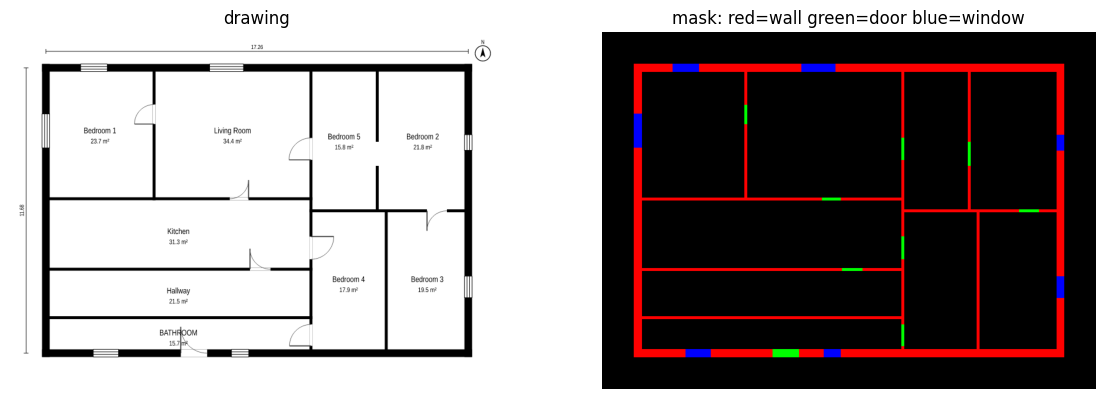

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(Image.open('ml/data/train/img_00000.png')); ax[0].set_title('drawing'); ax[0].axis('off')
ax[1].imshow(Image.open('ml/data/train/msk_00000.png')); ax[1].set_title('mask: red=wall green=door blue=window'); ax[1].axis('off')
plt.show()

## 6. Train

Watch the per‑class `val IoU`. Walls climb first; doors/windows lag (rarer pixels) but the class weights compensate. Good v1 targets: wall ≥ 0.85, door/window ≥ 0.6. `best.pt` is saved whenever val mIoU improves.

In [15]:
%cd /content/stride/ml/train
!python train.py --data ../data/train --out ../checkpoints \
    --epochs {EPOCHS} --batch {BATCH} --size {SIZE} --base {BASE} --val-frac 0.05
%cd /content/stride

/content/stride/ml/train
device: cuda
train 2687  val 141
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
params: 7.8M
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check

## 7. Try it on a held‑out plan

/content/stride/ml/train
wrote /content/pred_mask.png and /content/pred_analysis.json
walls: 7  doors: 4  windows: 5
/content/stride


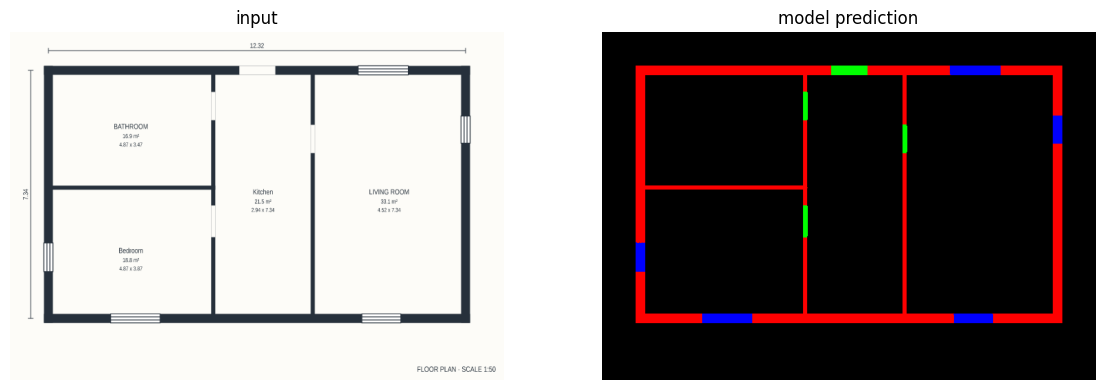

In [16]:
%cd /content/stride/ml/train
!python infer.py --checkpoint ../checkpoints/best.pt --base {BASE} \
    --image ../data/val/img_00003.png --out-prefix /content/pred
%cd /content/stride
from PIL import Image
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(Image.open('ml/data/val/img_00003.png')); ax[0].set_title('input'); ax[0].axis('off')
ax[1].imshow(Image.open('/content/pred_mask.png')); ax[1].set_title('model prediction'); ax[1].axis('off')
plt.show()

## 8. Export ONNX (for in‑browser inference in Stride)

In [17]:
!pip install --quiet onnx
%cd /content/stride/ml/train
import torch
from model import UNet
m = UNet(4, base=BASE)
m.load_state_dict(torch.load('../checkpoints/best.pt', map_location='cpu'))
m.eval()
torch.onnx.export(m, torch.zeros(1, 3, 512, 512), '/content/stride-planseg.onnx',
                  input_names=['image'], output_names=['logits'], opset_version=17,
                  dynamo=False, dynamic_axes={'image': {2: 'h', 3: 'w'}, 'logits': {2: 'h', 3: 'w'}})
%cd /content/stride
import os
print('ONNX size: %.1f MB' % (os.path.getsize('/content/stride-planseg.onnx') / 1e6))

/content/stride/ml/train


/tmp/ipykernel_3511/3754049817.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m, torch.zeros(1, 3, 512, 512), '/content/stride-planseg.onnx',


/content/stride
ONNX size: 31.1 MB


## 9. Download the trained model

In [20]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/stride-model
!cp /content/stride/ml/checkpoints/best.pt /content/drive/MyDrive/stride-model/
!cp /content/stride-planseg.onnx /content/drive/MyDrive/stride-model/
!ls -la /content/drive/MyDrive/stride-model/

Mounted at /content/drive
total 60700
-rw------- 1 root root 31070417 Jul  5 19:31 best.pt
-rw------- 1 root root 31085674 Jul  5 19:31 stride-planseg.onnx
